<a href="https://colab.research.google.com/github/Emo4ka07/VKR/blob/main/NTP_%D1%83%D0%B6_%D1%81_%D0%B5%D0%B6%D0%BE%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import random
import numpy as np
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import matplotlib.pyplot as plt

In [10]:
# Параметры
T = 500.0
N = 1000
dt = T / N
X_SCALE = 1000.0
C_SCALE = 1000.0
U_MAX = 500.0
ALPHA_U = 0.01

# Параметры системы в кортеже (графо-безопасно)
PARAMS = (0.002, 0.001, 0.49, 0.4632, 0.4425, 505.0, 505.0,
          0.6625, 0.435, 45.0, 30.0, 0.516, 0.45, 0.309, 0.001)

class Controller(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.d1 = tf.keras.layers.Dense(64, activation='leaky_relu')
        self.d2 = tf.keras.layers.Dense(32, activation='leaky_relu')
        self.d3 = tf.keras.layers.Dense(16, activation='leaky_relu')
        self.out = tf.keras.layers.Dense(1, activation='tanh')

    def call(self, x_norm, C_norm, ctrl_hot, tgt_hot):
        inp = tf.concat([x_norm, C_norm, ctrl_hot, tgt_hot], axis=-1)
        return tf.squeeze(self.out(self.d3(self.d2(self.d1(inp)))), axis=-1)

def dynamics(x, u_scaled, ctrl_idx, p):
    a1, a2, b1, r1, r2, K1, K2, w1, w2, d1, d2, g1, g2, m, m1 = p
    x1, x2, x3 = x[...,0], x[...,1], x[...,2]

    # Защита от деления на ноль
    den1 = d1 + x1 + 1e-6
    den2 = d2 + b1 * tf.square(x2) + 1e-6

    dx1 = r1*x1*(1.0 - (x1 + a1*x2)/K1) - (w1*x1*x3)/den1
    dx2 = r2*x2*(1.0 - (x2 + a2*x1)/K2) - (w2*x2*x3)/den2
    dx3 = (g1*x1*x3)/den1 - (g2*x2*x3)/den2 - m*x3 - m1*tf.square(x3)

    u = tf.reshape(u_scaled, tf.shape(x1))
    if ctrl_idx == 0: dx1 += u
    elif ctrl_idx == 1: dx2 += u
    else: dx3 += u

    return tf.stack([dx1, dx2, dx3], axis=-1)

def simulate_batch(x0, C_raw, controller, ctrl_idx, tgt_idx, p):
    batch = tf.shape(x0)[0]
    # One-hot создаем один раз на батч
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N):
        x_norm = x / X_SCALE
        C_norm = C_raw / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt * dx
        # Жесткое ограничение: биологические переменные не могут быть < 0
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_norm)

    traj = tf.stack(traj_list, axis=1)  # (batch, N, 3)
    u_stack = tf.stack(u_list, axis=1)  # (batch, N)
    return traj, u_stack

def batch_loss(controller, x0, C_raw, ctrl_idx, tgt_idx, p):
    traj, u_stack = simulate_batch(x0, C_raw, controller, ctrl_idx, tgt_idx, p)
    C_target = tf.reshape(C_raw, [-1, 1])

    # Ошибка в нормированном масштабе -> лосс ~0.1-1.0, нет взрывов
    err = (traj[:, :, tgt_idx] - C_target) / X_SCALE
    mse = tf.reduce_mean(tf.square(err))
    u_pen = tf.reduce_mean(tf.square(u_stack))
    return mse + ALPHA_U * u_pen

В следующей ячейке обучение

Epoch   1 | Train=0.1519 | Test=0.1870
Epoch   5 | Train=0.1259 | Test=0.0659
Epoch  10 | Train=0.0724 | Test=0.1604
Epoch  15 | Train=0.0849 | Test=0.0797
Epoch  20 | Train=0.1155 | Test=0.1136
Epoch  25 | Train=0.1111 | Test=0.1021
Epoch  30 | Train=0.0799 | Test=0.0642
Веса сохранены: /content/drive/MyDrive/controller_universal.weights.h5


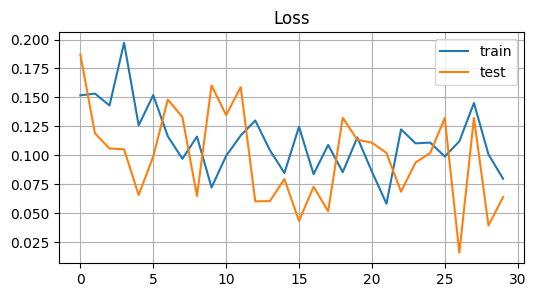

In [11]:
def make_samples(n):
    xs = np.random.uniform(10.0, 800.0, size=(n,3)).astype(np.float32)
    Cs = np.random.uniform(50.0, 900.0, size=(n,1)).astype(np.float32)
    return xs, Cs

np.random.seed(13)
train_xs, train_Cs = make_samples(400)
test_xs, test_Cs   = make_samples(100)

BATCH_SIZE = 64
train_dataset = tf.data.Dataset.from_tensor_slices((train_xs, train_Cs)).shuffle(len(train_xs)).batch(BATCH_SIZE)
test_dataset  = tf.data.Dataset.from_tensor_slices((test_xs, test_Cs)).batch(BATCH_SIZE)

controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))

optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4) # Чуть меньше LR для стабильности
EPOCHS = 30

train_losses, test_losses = [], []

for epoch in range(1, EPOCHS+1):
    epoch_loss = 0.0; nb = 0
    for bx, bC in train_dataset:
        # 🎲 Случайный случай для каждого батча
        c_idx = np.random.randint(0, 3)
        t_idx = np.random.randint(0, 3)

        with tf.GradientTape() as tape:
            loss = batch_loss(controller, bx, bC, c_idx, t_idx, PARAMS)

        grads = tape.gradient(loss, controller.trainable_variables)
        grads, _ = tf.clip_by_global_norm(grads, 1.0)
        optimizer.apply_gradients(zip(grads, controller.trainable_variables))
        epoch_loss += loss.numpy()
        nb += 1
    train_losses.append(epoch_loss / nb)

    # Тест на случайных случаях
    test_loss = 0.0; nb_t = 0
    for tx, tC in test_dataset:
        c_idx_t = np.random.randint(0, 3)
        t_idx_t = np.random.randint(0, 3)
        test_loss += batch_loss(controller, tx, tC, c_idx_t, t_idx_t, PARAMS).numpy()
        nb_t += 1
    test_losses.append(test_loss / nb_t)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Train={train_losses[-1]:.4f} | Test={test_losses[-1]:.4f}")

save_path = "/content/drive/MyDrive/controller_universal.weights.h5"
controller.save_weights(save_path)
print(f"Веса сохранены: {save_path}")

plt.figure(figsize=(6,3))
plt.plot(train_losses, label='train')
plt.plot(test_losses, label='test')
plt.legend(); plt.grid(); plt.title("Loss")
plt.show()

запуск, графики

Веса загружены
Демонстрация: u -> x2, цель -> x1


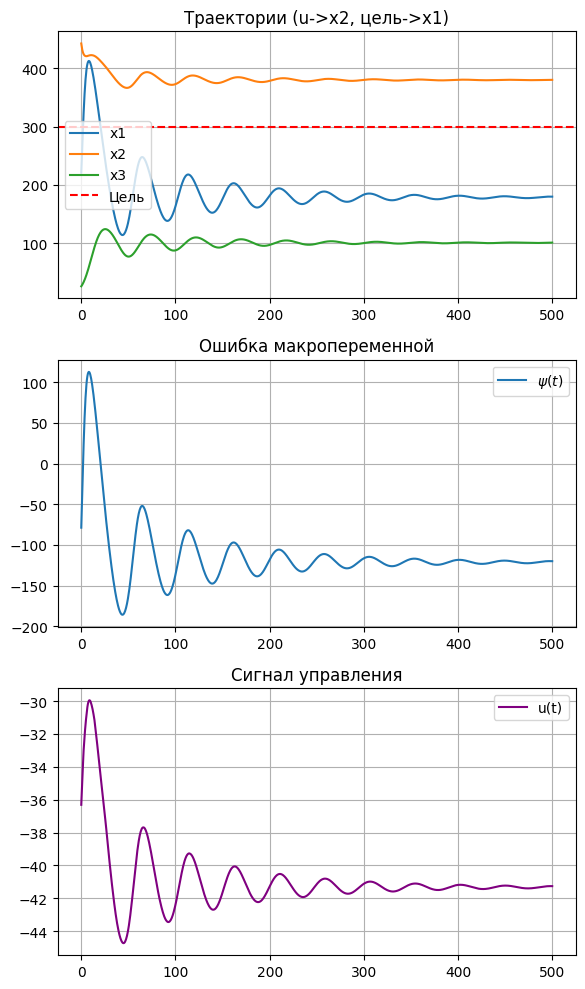

In [20]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 1  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 0  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

Веса загружены
Демонстрация: u -> x1, цель -> x2


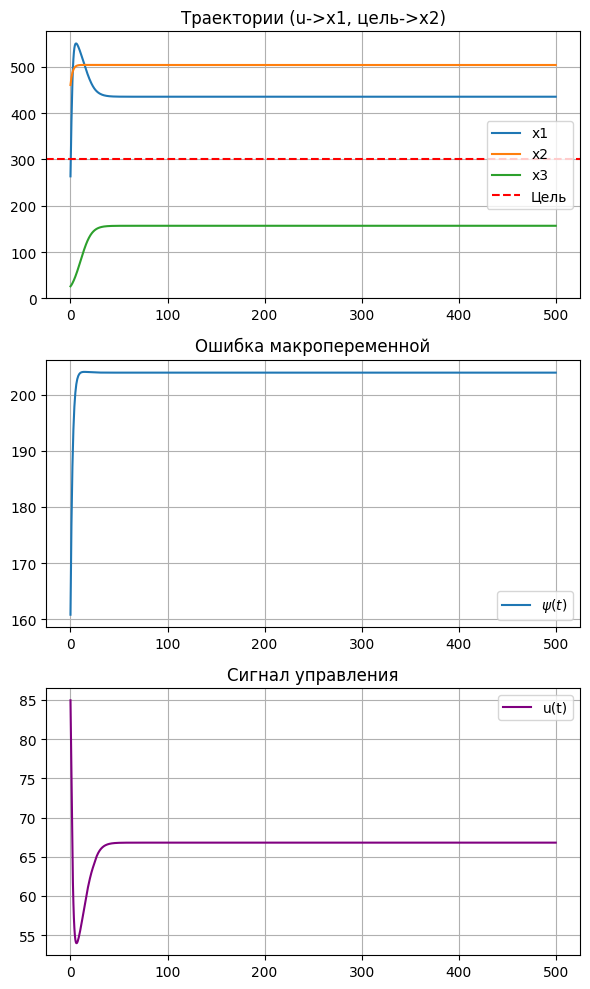

In [21]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 0  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 1  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

Веса загружены
Демонстрация: u -> x2, цель -> x2


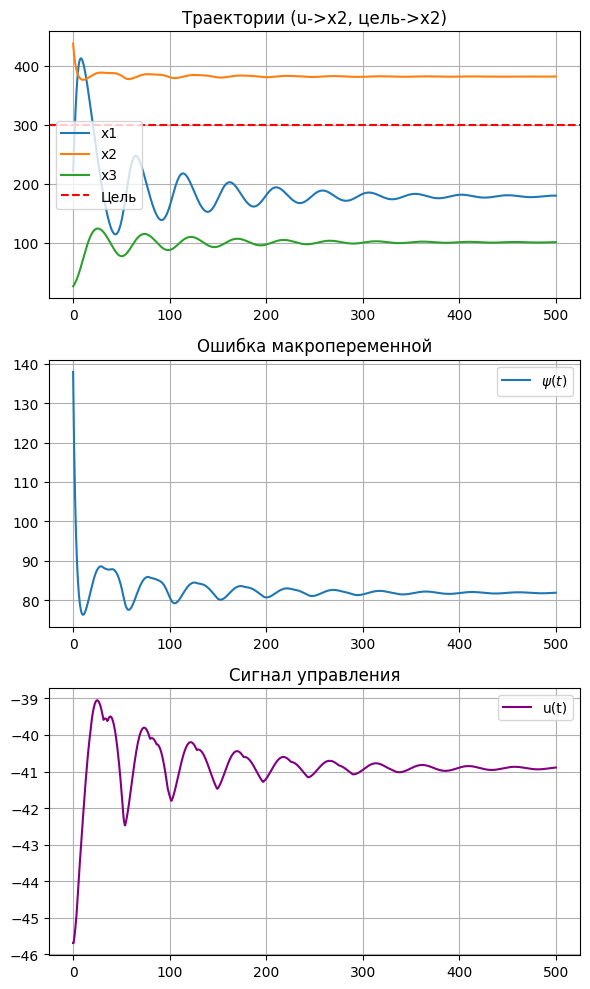

In [22]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 1  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 1  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

Веса загружены
Демонстрация: u -> x1, цель -> x1


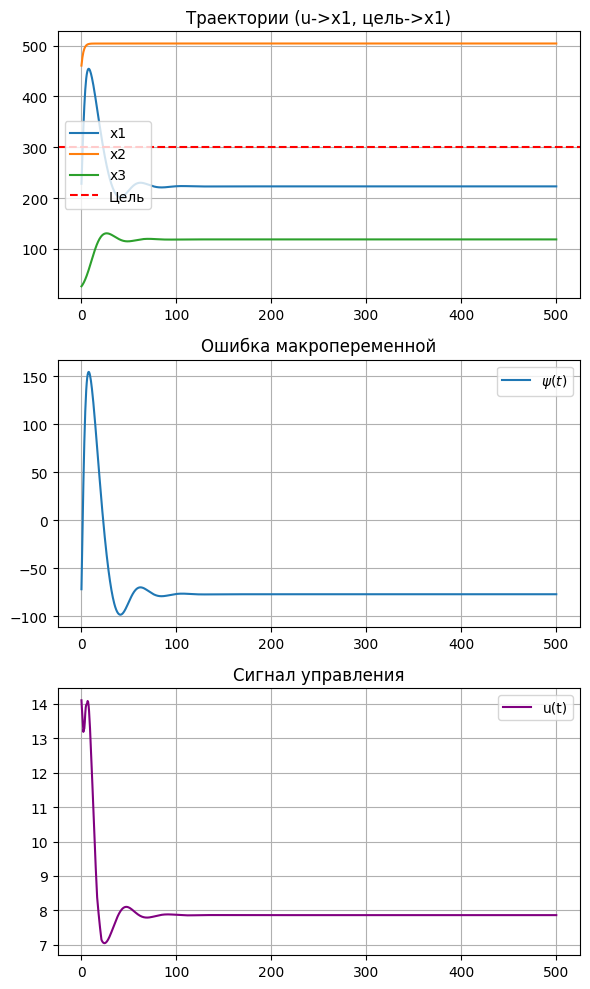

In [23]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 0  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 0  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

Веса загружены
Демонстрация: u -> x2, цель -> x3


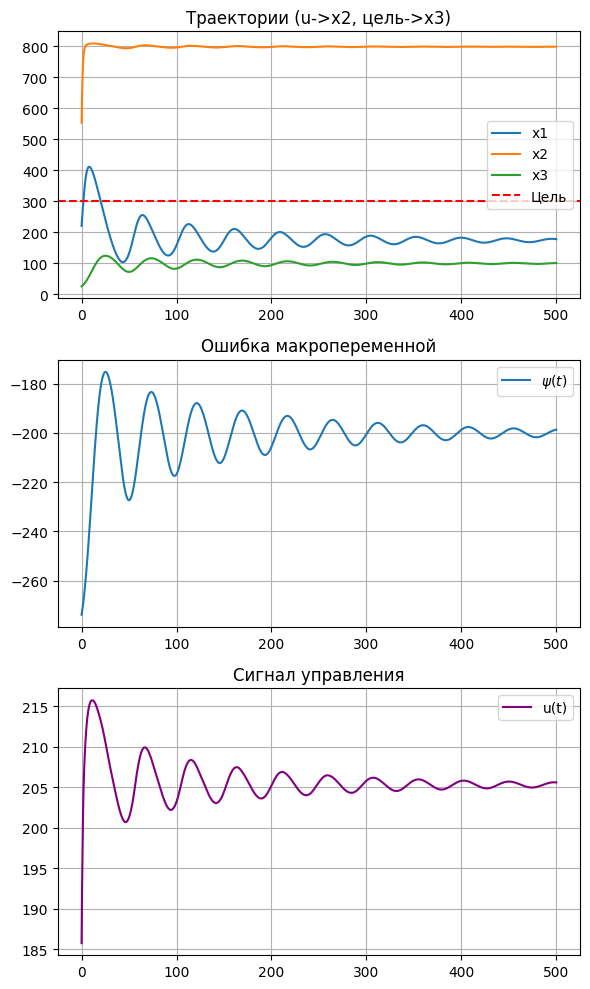

In [24]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 1  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 2  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()

Веса загружены
Демонстрация: u -> x1, цель -> x3


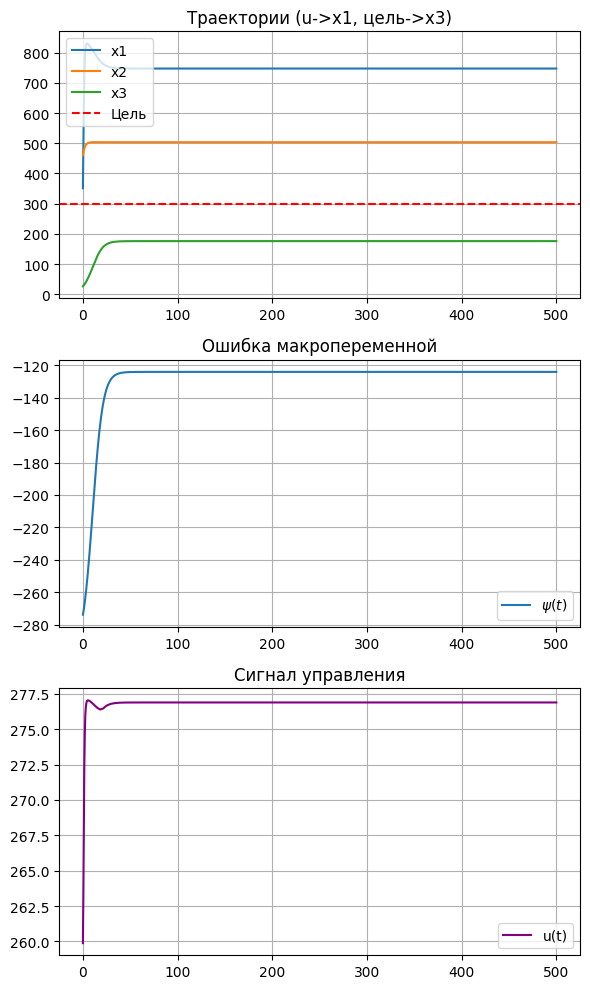

In [25]:
controller = Controller()
_ = controller(tf.zeros((1,3)), tf.zeros((1,1)), tf.zeros((1,3)), tf.zeros((1,3)))
controller.load_weights("/content/drive/MyDrive/controller_universal.weights.h5")
print("Веса загружены")

def simulate_demo(x0, C, ctrl_idx, tgt_idx, controller, p, N_sim=1000):
    T_sim = 500.0; dt_sim = T_sim / N_sim
    batch = tf.shape(x0)[0]
    ctrl_hot = tf.tile(tf.one_hot([ctrl_idx], 3), [batch, 1])
    tgt_hot  = tf.tile(tf.one_hot([tgt_idx], 3), [batch, 1])

    x = x0
    traj_list, u_list = [], []

    for _ in range(N_sim):
        x_norm = x / X_SCALE; C_norm = C / C_SCALE
        u_norm = controller(x_norm, C_norm, ctrl_hot, tgt_hot)
        u_scaled = u_norm * U_MAX

        dx = dynamics(x, u_scaled, ctrl_idx, p)
        x = x + dt_sim * dx
        x = tf.clip_by_value(x, 1e-3, 2000.0)

        traj_list.append(x)
        u_list.append(u_scaled)

    return tf.stack(traj_list, axis=1).numpy()[0], tf.stack(u_list, axis=1).numpy()[0]

# индексы
demo_ctrl = 0  # управление по: 0->x1, 1->x2, 2->x3
demo_tgt  = 2  # цель:          0->x1, 1->x2, 2->x3
print(f"Демонстрация: u -> x{demo_ctrl+1}, цель -> x{demo_tgt+1}")

demo_x = np.array([[200.0, 450.0, 25.1]], np.float32)
demo_C = np.array([[300.0]], np.float32)

traj, u = simulate_demo(demo_x, demo_C, demo_ctrl, demo_tgt, controller, PARAMS)
ts_plot = np.linspace(0, 500.0, len(u))
psi = traj[:, demo_tgt] - demo_C[0,0]

plt.figure(figsize=(6,10))
plt.subplot(3,1,1)
for i, lbl in enumerate(['x1', 'x2', 'x3']):
    plt.plot(ts_plot, traj[:,i], label=lbl)
plt.axhline(demo_C[0,0], color='red', linestyle='--', label='Цель')
plt.title(f"Траектории (u->x{demo_ctrl+1}, цель->x{demo_tgt+1})")
plt.grid(); plt.legend()

plt.subplot(3,1,2)
plt.plot(ts_plot, psi, label=r'$\psi(t)$')
plt.title("Ошибка макропеременной")
plt.grid(); plt.legend()

plt.subplot(3,1,3)
plt.plot(ts_plot, u, label='u(t)', color='purple')
plt.title("Сигнал управления")
plt.grid(); plt.legend()

plt.tight_layout()
plt.show()